In [1]:
from google.colab import files
uploaded=files.upload()

Saving online_retail.csv.zip to online_retail.csv.zip


In [19]:
import pandas as pd
df=pd.read_csv('online_retail.csv.zip', encoding='latin1')
print(df)
print(df.head())
print(df.info())

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  CustomerID         Country  
0     

### Handling Missing Values

Based on the `df.info()` output, we can see that 'Description' and 'CustomerID' columns have non-null counts less than the total number of entries, indicating missing values. I will drop rows with missing values in these columns to ensure data quality for subsequent analysis.

In [17]:
# Drop rows where 'Description' or 'CustomerID' are null
df.dropna(subset=['Description', 'CustomerID'], inplace=True)

# Display the info of the DataFrame after dropping nulls to verify
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB
None


### Checking for Duplicate Values

It's important to identify and handle duplicate entries in the dataset, as they can bias analysis and models. I will count the number of fully duplicated rows in the DataFrame.

In [18]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 5225


### Removing Duplicate Rows

Since duplicate entries were found, I will now remove them to ensure the uniqueness of each record in the dataset. After removal, I'll print the DataFrame's shape to verify the change.

In [23]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify that duplicates have been removed by checking the new shape of the DataFrame
print(f"Shape of DataFrame after removing duplicates: {df.shape}")

Shape of DataFrame after removing duplicates: (536641, 8)


### Data Type Conversion and Invalid Value Handling

To ensure proper analysis, I will convert `InvoiceDate` to datetime objects and `CustomerID` to integer type. Additionally, I'll examine `Quantity` and `UnitPrice` columns for values that don't make sense in a retail context (e.g., negative or zero quantities/prices).

In [31]:
import numpy as np

# Re-apply filtering for finite CustomerID values as a defensive measure
# This ensures no NaN or inf values are present before type conversion
initial_customer_rows = df.shape[0]
df = df[np.isfinite(df['CustomerID'])]
removed_customer_rows = initial_customer_rows - df.shape[0]

if removed_customer_rows > 0:
    print(f"Removed {removed_customer_rows} rows due to non-finite CustomerID values before conversion.")

# Convert 'CustomerID' to integer type after ensuring all values are finite
df['CustomerID'] = df['CustomerID'].astype(int)

# Display the info of the DataFrame after type conversion
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB
None


### Handling Non-Positive Quantity and UnitPrice

As observed previously, there are rows with non-positive ('Quantity' <= 0) and ('UnitPrice' <= 0) values. These are typically invalid in a retail sales dataset and should be removed to ensure the accuracy of further analysis.

In [27]:
# Remove rows with non-positive Quantity
initial_rows_quantity = df.shape[0]
df = df[df['Quantity'] > 0]
removed_rows_quantity = initial_rows_quantity - df.shape[0]
print(f"Removed {removed_rows_quantity} rows due to non-positive Quantity.")

# Remove rows with non-positive UnitPrice
initial_rows_unitprice = df.shape[0]
df = df[df['UnitPrice'] > 0]
removed_rows_unitprice = initial_rows_unitprice - df.shape[0]
print(f"Removed {removed_rows_unitprice} rows due to non-positive UnitPrice.")

# Display the info of the DataFrame after these removals
print(df.info())

Removed 8872 rows due to non-positive Quantity.
Removed 40 rows due to non-positive UnitPrice.
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB
None


In [28]:
# Remove rows with non-positive Quantity
initial_rows_quantity = df.shape[0]
df = df[df['Quantity'] > 0]
removed_rows_quantity = initial_rows_quantity - df.shape[0]
print(f"Removed {removed_rows_quantity} rows due to non-positive Quantity.")

# Remove rows with non-positive UnitPrice
initial_rows_unitprice = df.shape[0]
df = df[df['UnitPrice'] > 0]
removed_rows_unitprice = initial_rows_unitprice - df.shape[0]
print(f"Removed {removed_rows_unitprice} rows due to non-positive UnitPrice.")

# Display the info of the DataFrame after these removals
print(df.info())

Removed 0 rows due to non-positive Quantity.
Removed 0 rows due to non-positive UnitPrice.
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB
None


In [30]:
# Check for negative or zero Quantity
negative_quantity_count = df[df['Quantity'] <= 0].shape[0]
print(f"Number of rows with non-positive Quantity: {negative_quantity_count}")

# Check for negative or zero UnitPrice
negative_unitprice_count = df[df['UnitPrice'] <= 0].shape[0]
print(f"Number of rows with non-positive UnitPrice: {negative_unitprice_count}")

Number of rows with non-positive Quantity: 0
Number of rows with non-positive UnitPrice: 0


### Feature Engineering

Now that the data is cleaned, we can proceed with creating new features that might be useful for analysis or modeling. We'll start by calculating the `TotalPrice` for each transaction line item and extracting time-based features from the `InvoiceDate`.

In [32]:
# Calculate TotalPrice for each row
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("DataFrame after adding 'TotalPrice':")
display(df.head())

DataFrame after adding 'TotalPrice':


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [33]:
# Extract time-based features from InvoiceDate
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

print("DataFrame after adding time-based features:")
display(df.head())

DataFrame after adding time-based features:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,2,8


In [34]:
# Display info to see the new columns and their types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392692 non-null  object        
 1   StockCode         392692 non-null  object        
 2   Description       392692 non-null  object        
 3   Quantity          392692 non-null  int64         
 4   InvoiceDate       392692 non-null  datetime64[ns]
 5   UnitPrice         392692 non-null  float64       
 6   CustomerID        392692 non-null  int64         
 7   Country           392692 non-null  object        
 8   TotalPrice        392692 non-null  float64       
 9   InvoiceYear       392692 non-null  int32         
 10  InvoiceMonth      392692 non-null  int32         
 11  InvoiceDay        392692 non-null  int32         
 12  InvoiceDayOfWeek  392692 non-null  int32         
 13  InvoiceHour       392692 non-null  int32         
dtypes: dateti

### Sales Trends Analysis

Let's analyze the sales data to identify various trends, including monthly sales growth, peak sales days, and hour-wise purchases. This will help us understand the business performance over time.

#### Monthly Sales Growth

First, we'll calculate the total sales for each month and then determine the month-over-month growth.

In [35]:
# Aggregate sales by month
monthly_sales = df.groupby(['InvoiceYear', 'InvoiceMonth'])['TotalPrice'].sum().reset_index()
monthly_sales['InvoiceDate'] = pd.to_datetime(monthly_sales['InvoiceYear'].astype(str) + '-' + monthly_sales['InvoiceMonth'].astype(str) + '-01')
monthly_sales = monthly_sales.sort_values('InvoiceDate')

# Calculate monthly sales growth
monthly_sales['MonthlyGrowth'] = monthly_sales['TotalPrice'].pct_change() * 100

print("Monthly Sales and Growth:")
display(monthly_sales)

Monthly Sales and Growth:


,InvoiceYear,InvoiceMonth,TotalPrice,InvoiceDate,MonthlyGrowth
0,2010,12,570422.730,2010-12-01,NaN
1,2011,1,568101.310,2011-01-01,-0.406965
2,2011,2,446084.920,2011-02-01,-21.477928
3,2011,3,594081.760,2011-03-01,33.176831
4,2011,4,468374.331,2011-04-01,-21.159954
5,2011,5,677355.150,2011-05-01,44.618333
6,2011,6,660046.050,2011-06-01,-2.555395
7,2011,7,598962.901,2011-07-01,-9.254377
8,2011,8,644051.040,2011-08-01,7.527701
9,2011,9,950690.202,2011-09-01,47.611003


#### Monthly Sales Trend Visualization

To better understand the overall sales performance, let's visualize the total sales per month.

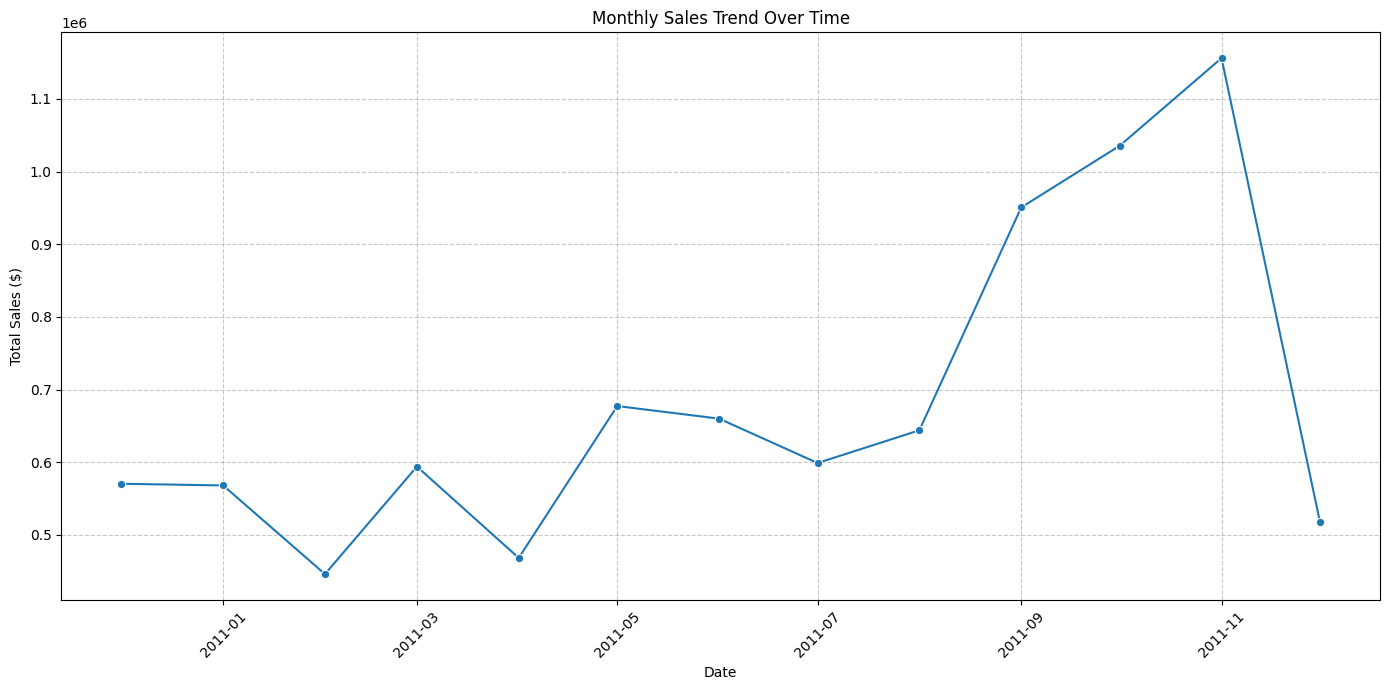

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='InvoiceDate', y='TotalPrice', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Total Sales by Day of the Week

To further analyze revenue trends, let's visualize the total sales for each day of the week to identify peak sales days.

#### Monthly Sales Growth Visualization

Now, let's visualize the month-over-month sales growth to identify periods of significant expansion or contraction.

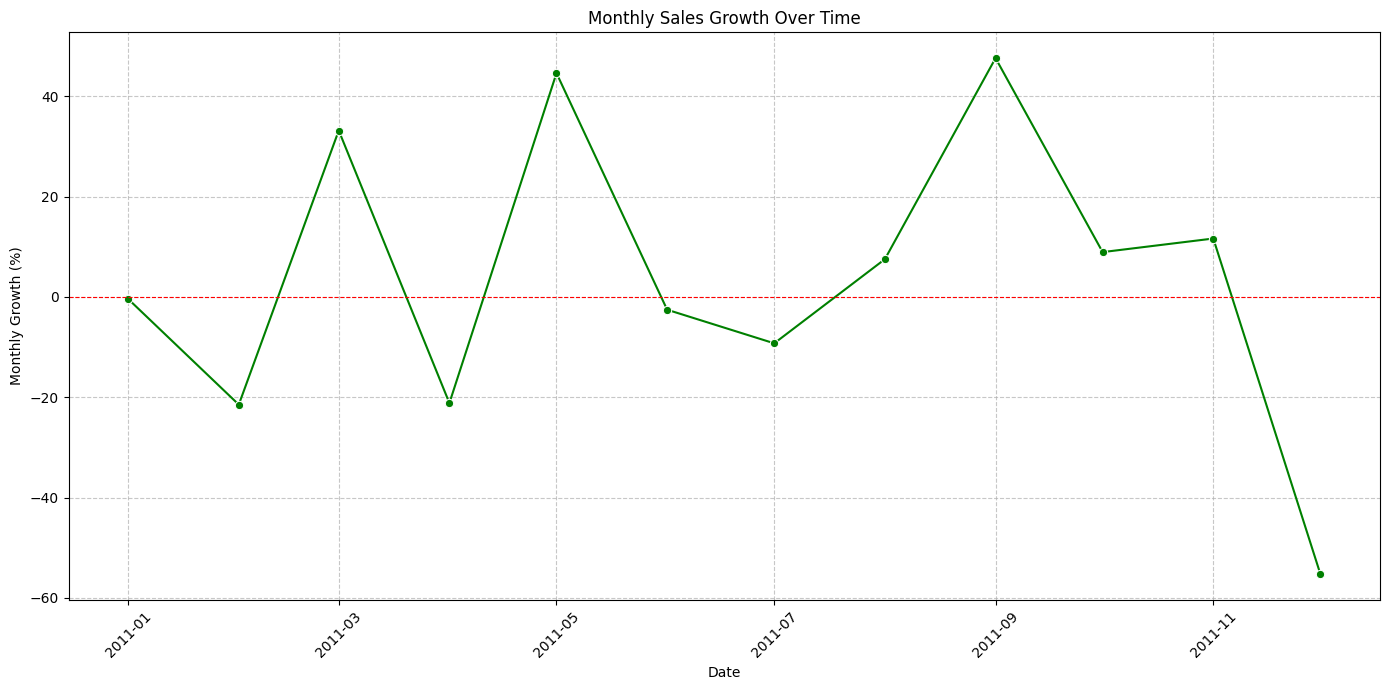

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='InvoiceDate', y='MonthlyGrowth', data=monthly_sales, marker='o', color='green')
plt.title('Monthly Sales Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Monthly Growth (%)')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a line at 0 for reference
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Weekly Sales Trend

To complement our monthly and daily analyses, let's look at the total sales aggregated by week to observe weekly revenue patterns.

Weekly Sales:


,InvoiceYearWeek,TotalPrice
0,2010-48,148627.97
1,2010-49,212619.13
2,2010-50,163116.12
3,2010-51,46059.51
4,2011-01,114636.80


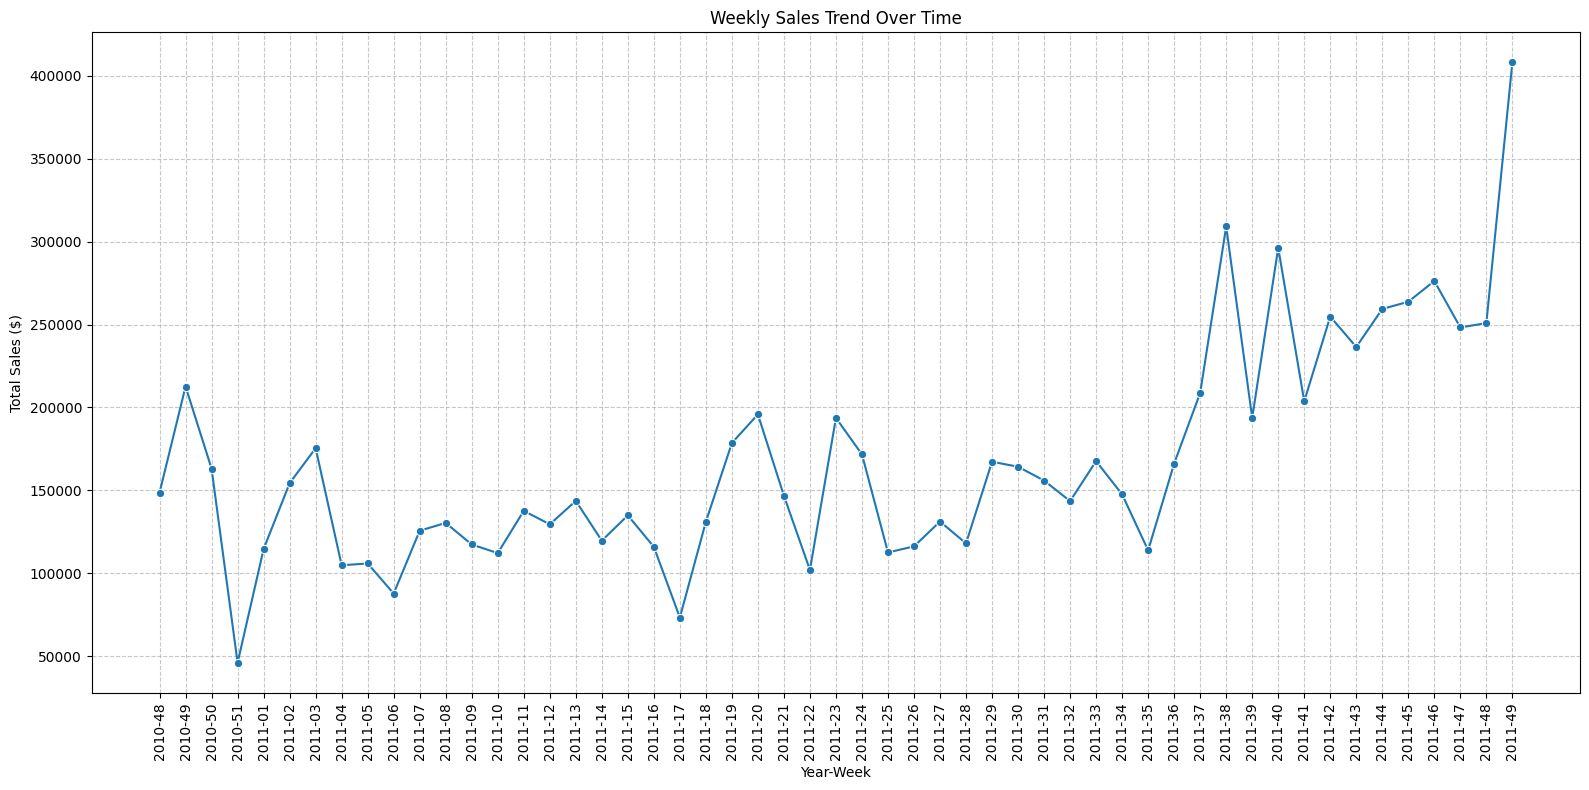

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract week of year and year for grouping
df['InvoiceWeek'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['InvoiceYearWeek'] = df['InvoiceDate'].dt.strftime('%Y-%W')

# Aggregate sales by week
weekly_sales = df.groupby('InvoiceYearWeek')['TotalPrice'].sum().reset_index()
weekly_sales = weekly_sales.sort_values('InvoiceYearWeek')

print("Weekly Sales:")
display(weekly_sales.head())

# Visualize weekly sales trend
plt.figure(figsize=(16, 8))
sns.lineplot(x='InvoiceYearWeek', y='TotalPrice', data=weekly_sales, marker='o')
plt.title('Weekly Sales Trend Over Time')
plt.xlabel('Year-Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Peak Sales Days

Next, let's determine which days of the week have the highest sales on average.

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map day of week numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeekName'] = df['InvoiceDayOfWeek'].map(lambda x: day_names[x])

# Aggregate total sales by day of the week
daily_sales = df.groupby('DayOfWeekName')['TotalPrice'].sum().reindex(day_names).reset_index()

print("Total Sales by Day of the Week:")
display(daily_sales)


Total Sales by Day of the Week:


,DayOfWeekName,TotalPrice
0,Monday,1363604.401
1,Tuesday,1697733.801
2,Wednesday,1584283.830
3,Thursday,1973015.730
4,Friday,1483080.811
5,Saturday,NaN
6,Sunday,785490.321


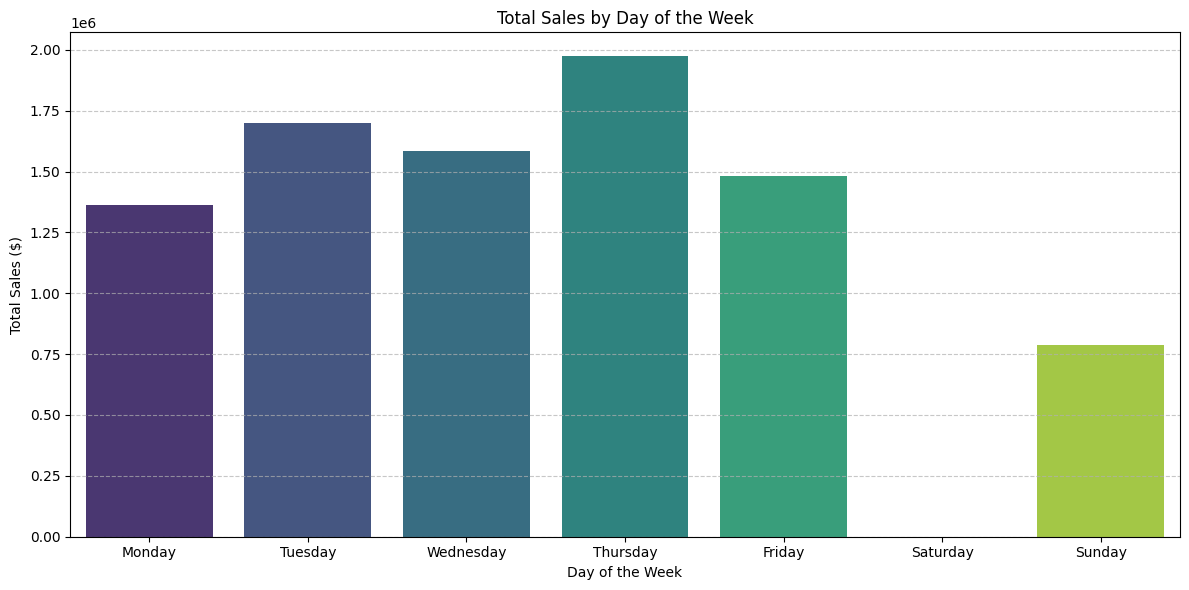

In [72]:
# Visualize total sales by day of the week
plt.figure(figsize=(12, 6))
sns.barplot(x='DayOfWeekName', y='TotalPrice', data=daily_sales, palette='viridis', hue='DayOfWeekName', legend=False)
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Investigating Missing Saturday Sales

The `NaN` value for Saturday's sales suggests that there might be no transactions occurring on Saturdays in our filtered dataset. Let's verify this by checking the unique values of `InvoiceDayOfWeek` and counting the occurrences of each day.

In [ ]:
# Check the value counts for InvoiceDayOfWeek
print("Count of transactions per day of the week (0=Monday, 6=Sunday):")
display(df['InvoiceDayOfWeek'].value_counts().sort_index())

# Check if there are any entries for Saturday (InvoiceDayOfWeek == 5)
saturday_transactions = df[df['InvoiceDayOfWeek'] == 5]
if saturday_transactions.empty:
    print("\nThere are no transactions recorded for Saturdays (InvoiceDayOfWeek == 5) in the dataset.")
else:
    print(f"\nThere are {len(saturday_transactions)} transactions recorded for Saturdays.")
    display(saturday_transactions.head())


#### Hour-wise Purchases

Finally, we'll examine the distribution of purchases throughout the day to identify peak hours.

Total Sales by Hour of the Day:


,InvoiceHour,TotalPrice
0,6,4.250
1,7,31059.210
2,8,281997.790
3,9,842392.341
4,10,1259267.591
5,11,1101177.600
6,12,1373695.390
7,13,1168724.200
8,14,991992.821
9,15,963559.680


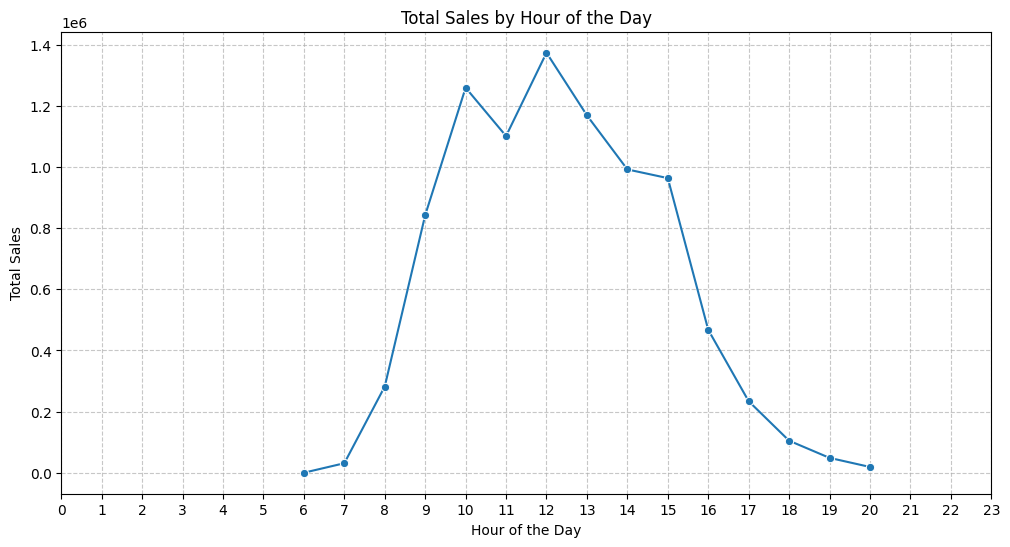

In [37]:
# Aggregate purchases by hour of the day
hourly_purchases = df.groupby('InvoiceHour')['TotalPrice'].sum().reset_index()

print("Total Sales by Hour of the Day:")
display(hourly_purchases)

# Visualize hour-wise purchases
plt.figure(figsize=(12, 6))
sns.lineplot(x='InvoiceHour', y='TotalPrice', data=hourly_purchases, marker='o')
plt.title('Total Sales by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Sales')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Product Insights

Now, let's analyze product performance to identify top-selling and most profitable items. This information can be crucial for inventory management, marketing strategies, and product development.

#### Top-Selling Products (by Quantity)

We'll identify the products that have been sold in the highest quantities.

Top 10 Selling Products by Quantity:


,Description,StockCode,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",23843,80995
1,MEDIUM CERAMIC TOP STORAGE JAR,23166,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84077,54319
3,JUMBO BAG RED RETROSPOT,85099B,46078
4,WHITE HANGING HEART T-LIGHT HOLDER,85123A,36706
5,ASSORTED COLOUR BIRD ORNAMENT,84879,35263
6,PACK OF 72 RETROSPOT CAKE CASES,21212,33670
7,POPCORN HOLDER,22197,30919
8,RABBIT NIGHT LIGHT,23084,27153
9,MINI PAINT SET VINTAGE,22492,26076


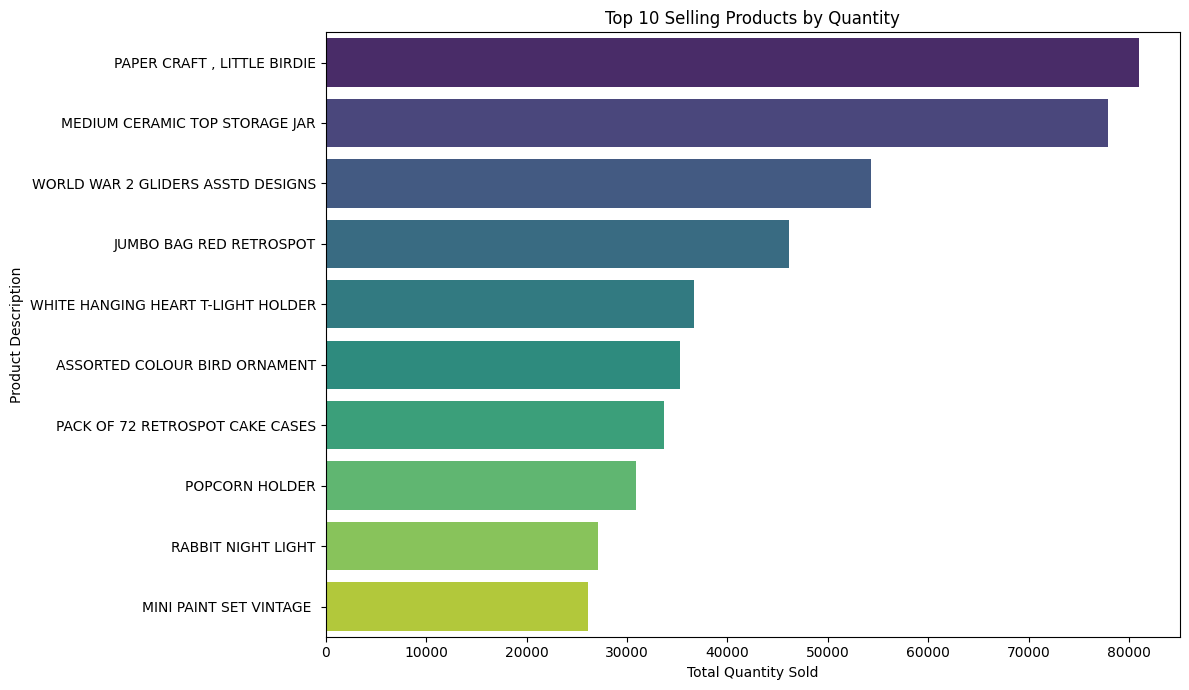

In [65]:
# Group by Description and StockCode to find top-selling products by quantity
top_selling_products = df.groupby(['Description', 'StockCode'])['Quantity'].sum().nlargest(10).reset_index()

print("Top 10 Selling Products by Quantity:")
display(top_selling_products)

# Visualize top-selling products
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Quantity', y='Description', data=top_selling_products, palette='viridis', hue='Description', legend=False)
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

#### Most Profitable Items (by TotalPrice)

Next, let's identify the products that generate the most revenue.

Top 10 Most Profitable Items by TotalPrice:


,Description,StockCode,TotalPrice
0,"PAPER CRAFT , LITTLE BIRDIE",23843,168469.60
1,REGENCY CAKESTAND 3 TIER,22423,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,85123A,100392.10
3,JUMBO BAG RED RETROSPOT,85099B,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,23166,81416.73
5,POSTAGE,POST,77803.96
6,PARTY BUNTING,47566,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,84879,56413.03
8,Manual,M,53419.93
9,RABBIT NIGHT LIGHT,23084,51251.24


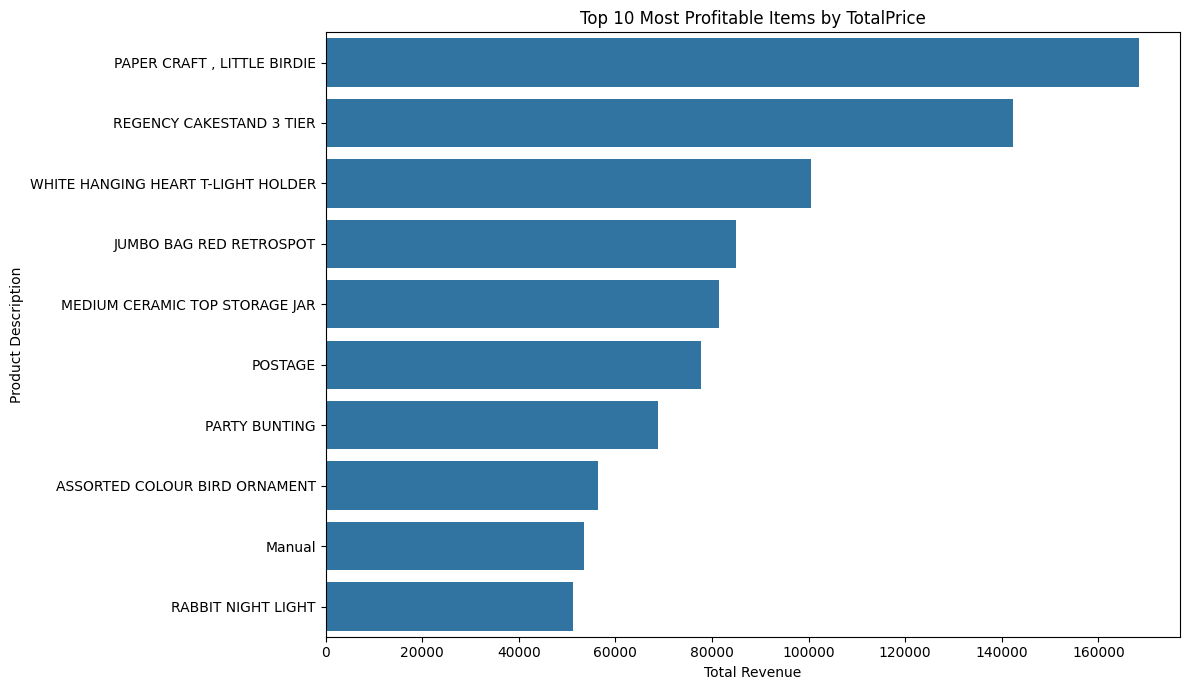

In [54]:
# Group by Description and StockCode to find most profitable items by TotalPrice
most_profitable_items = df.groupby(['Description', 'StockCode'])['TotalPrice'].sum().nlargest(10).reset_index()

print("Top 10 Most Profitable Items by TotalPrice:")
display(most_profitable_items)

# Visualize most profitable items
plt.figure(figsize=(12, 7))
sns.barplot(x='TotalPrice', y='Description', data=most_profitable_items, palette='plasma', hue='Description', legend=False)
plt.title('Top 10 Most Profitable Items by TotalPrice')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

#### Correlation Analysis

To understand the relationships between different numerical variables, let's compute and visualize the correlation matrix.

Correlation Matrix:


,Quantity,UnitPrice,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour
Quantity,1.000000,-0.004578,0.914451,0.001469,-0.004040,-0.001161,-0.007741,-0.014665
UnitPrice,-0.004578,1.000000,0.081619,-0.000203,-0.005063,-0.001297,-0.006537,-0.000217
TotalPrice,0.914451,0.081619,1.000000,0.000349,-0.002562,-0.001992,-0.007393,-0.013093
InvoiceYear,0.001469,-0.000203,0.000349,1.000000,-0.340599,0.168157,-0.017128,-0.019772
InvoiceMonth,-0.004040,-0.005063,-0.002562,-0.340599,1.000000,-0.117213,0.025799,0.058442
InvoiceDay,-0.001161,-0.001297,-0.001992,0.168157,-0.117213,1.000000,-0.005131,0.008961
InvoiceDayOfWeek,-0.007741,-0.006537,-0.007393,-0.017128,0.025799,-0.005131,1.000000,0.036611
InvoiceHour,-0.014665,-0.000217,-0.013093,-0.019772,0.058442,0.008961,0.036611,1.000000


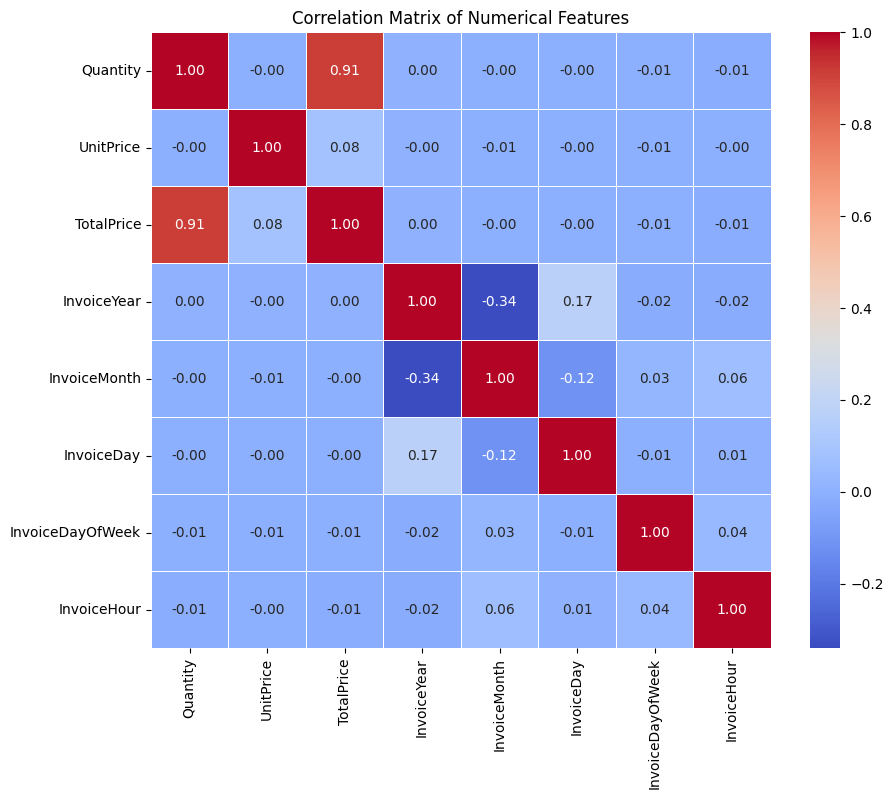

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation analysis
numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'InvoiceYear', 'InvoiceMonth', 'InvoiceDay', 'InvoiceDayOfWeek', 'InvoiceHour']
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Distribution Analysis of Numerical Features

Understanding the distribution of numerical features provides insights into their central tendency, spread, and the presence of outliers. Let's visualize the distributions of `Quantity`, `UnitPrice`, and `TotalPrice`.

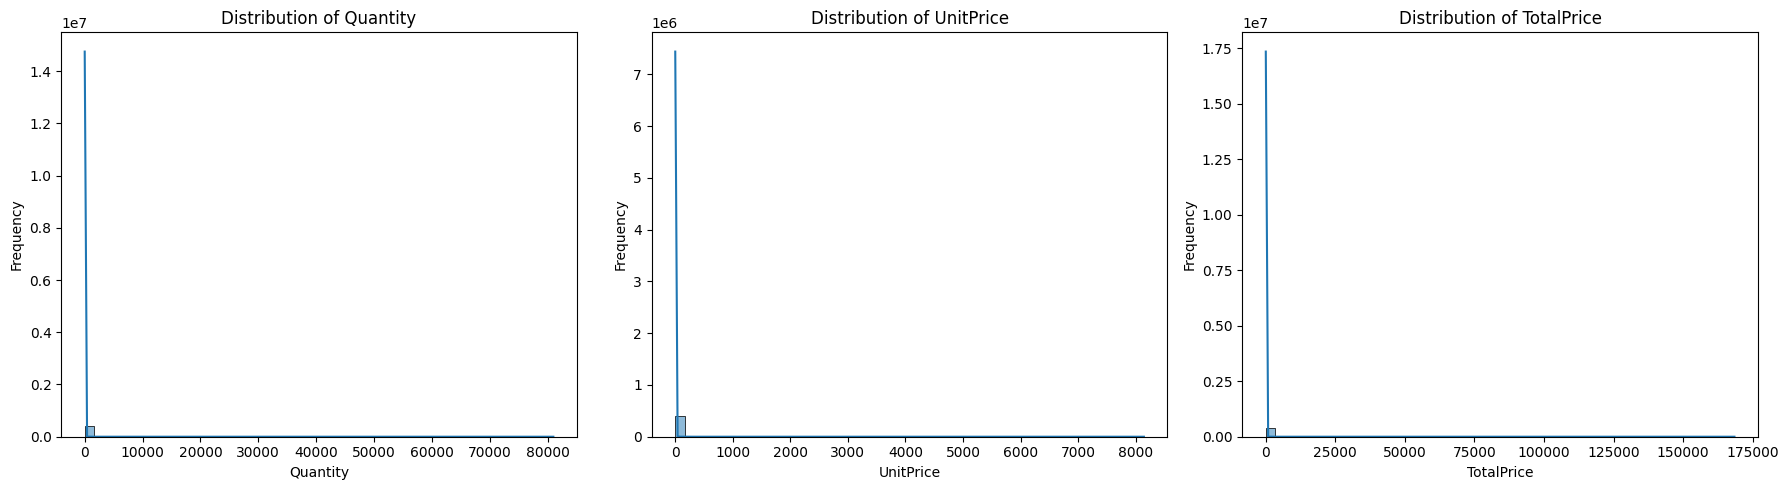

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Quantity'], bins=50, kde=True)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['UnitPrice'], bins=50, kde=True)
plt.title('Distribution of UnitPrice')
plt.xlabel('UnitPrice')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['TotalPrice'], bins=50, kde=True)
plt.title('Distribution of TotalPrice')
plt.xlabel('TotalPrice')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Customer Insights

Understanding customer behavior is crucial for targeted marketing and customer retention strategies. Let's identify our highest-spending customers and frequent buyers.

#### Highest Spending Customers

We'll identify the top customers based on their total spending.

Top 10 Highest Spending Customers:


,CustomerID,TotalPrice
0,14646,280206.02
1,18102,259657.30
2,17450,194390.79
3,16446,168472.50
4,14911,143711.17
5,12415,124914.53
6,14156,117210.08
7,17511,91062.38
8,16029,80850.84
9,12346,77183.60


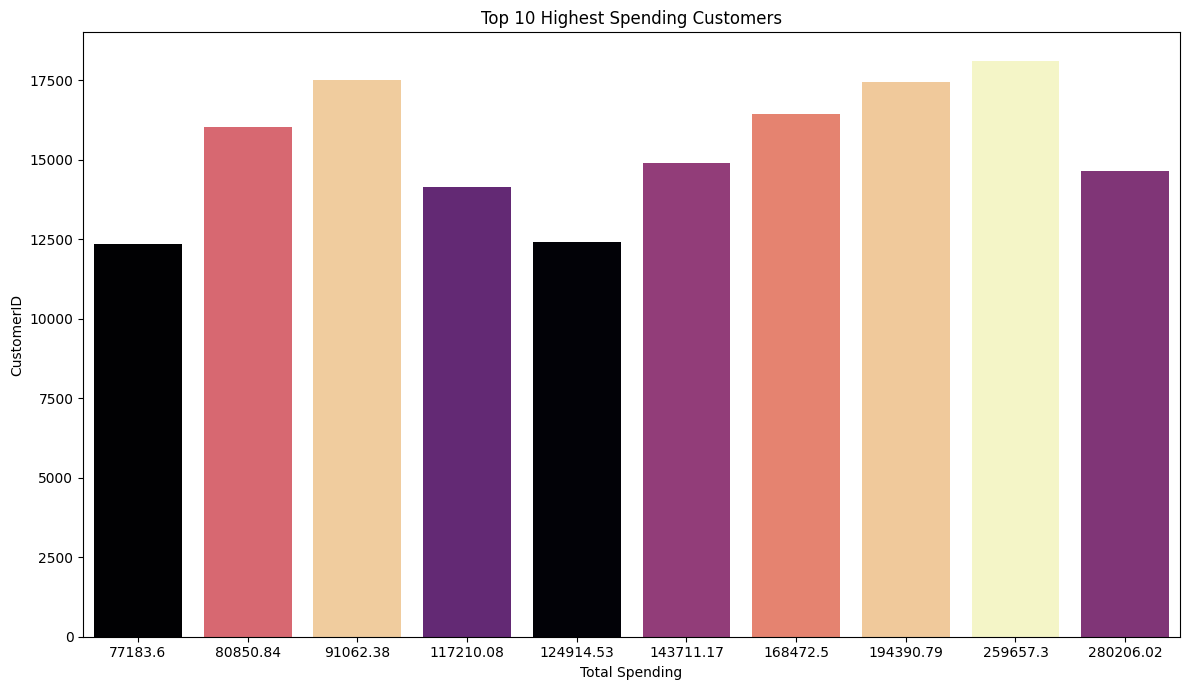

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by CustomerID and sum TotalPrice to find highest spending customers
highest_spending_customers = df.groupby('CustomerID')['TotalPrice'].sum().nlargest(10).reset_index()

print("Top 10 Highest Spending Customers:")
display(highest_spending_customers)

# Visualize highest spending customers
plt.figure(figsize=(12, 7))
sns.barplot(x='TotalPrice', y='CustomerID', data=highest_spending_customers.sort_values(by='TotalPrice', ascending=False), palette='magma', hue='CustomerID', legend=False)
plt.title('Top 10 Highest Spending Customers')
plt.xlabel('Total Spending')
plt.ylabel('CustomerID')
plt.tight_layout()
plt.show()

#### Frequent Buyers

Next, we'll identify customers who make the most frequent purchases.

Top 10 Frequent Buyers:


,CustomerID,NumberOfPurchases
0,12748,209
1,14911,201
2,17841,124
3,13089,97
4,14606,93
5,15311,91
6,12971,86
7,14646,73
8,16029,63
9,13408,62


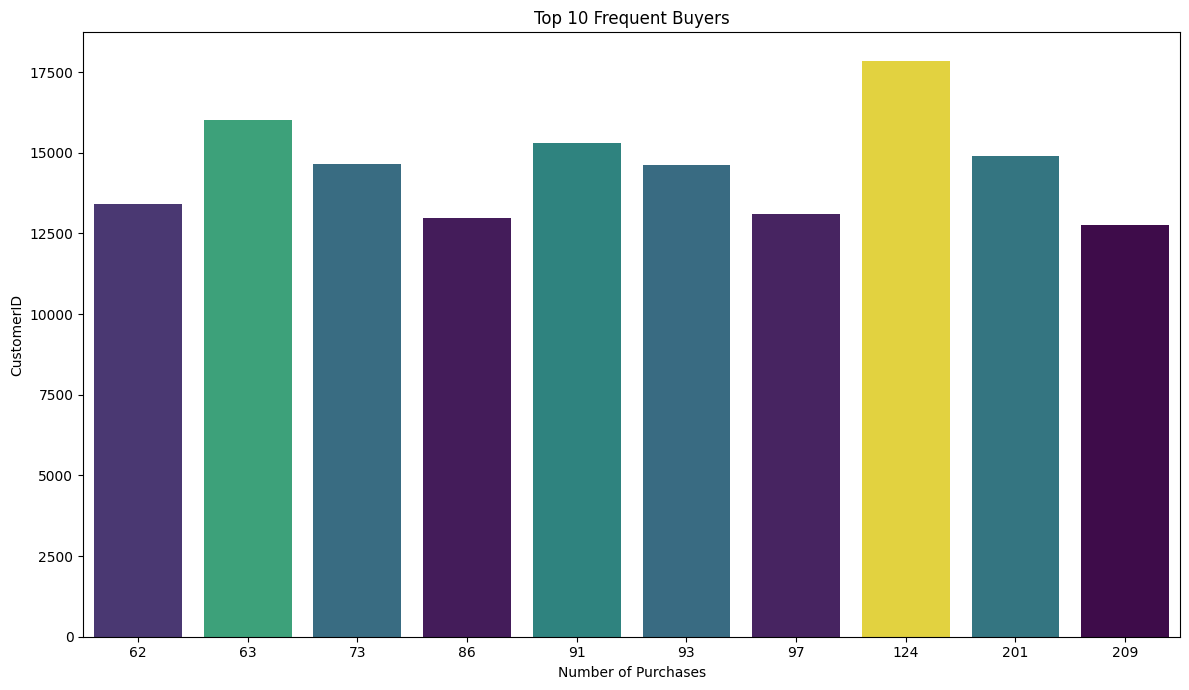

In [50]:
# Group by CustomerID and count unique InvoiceNo to find frequent buyers
frequent_buyers = df.groupby('CustomerID')['InvoiceNo'].nunique().nlargest(10).reset_index()
frequent_buyers.rename(columns={'InvoiceNo': 'NumberOfPurchases'}, inplace=True)

print("Top 10 Frequent Buyers:")
display(frequent_buyers)

# Visualize frequent buyers
plt.figure(figsize=(12, 7))
sns.barplot(x='NumberOfPurchases', y='CustomerID', data=frequent_buyers.sort_values(by='NumberOfPurchases', ascending=False), palette='viridis', hue='CustomerID', legend=False)
plt.title('Top 10 Frequent Buyers')
plt.xlabel('Number of Purchases')
plt.ylabel('CustomerID')
plt.tight_layout()
plt.show()

### Geographic Analysis

Understanding sales distribution by country can help identify key markets and potential areas for expansion. Let's analyze the total sales by country.

Top 10 Countries by Total Sales:


,Country,TotalPrice
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


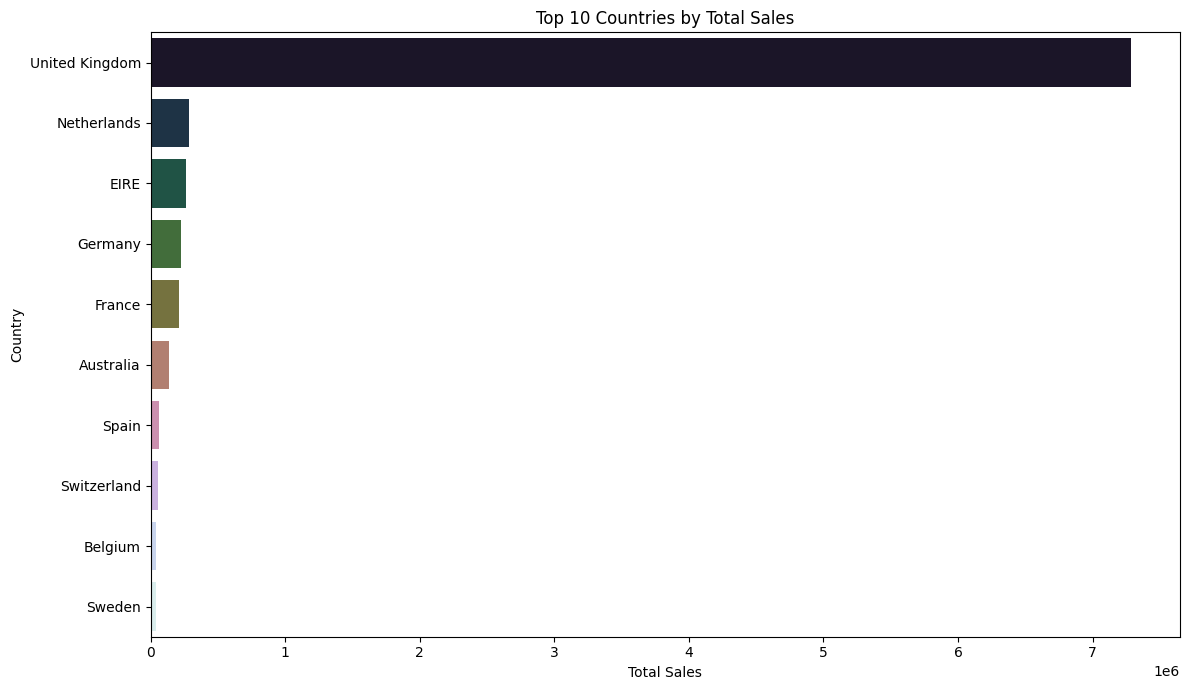

In [45]:
# Aggregate sales by Country
country_sales = df.groupby('Country')['TotalPrice'].sum().nlargest(10).reset_index()

print("Top 10 Countries by Total Sales:")
display(country_sales)

# Visualize country-wise sales
plt.figure(figsize=(12, 7))
sns.barplot(x='TotalPrice', y='Country', data=country_sales, palette='cubehelix', hue='Country', legend=False)
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Customer Segmentation

Customer segmentation is the process of dividing customers into groups based on common characteristics. This can help businesses to target marketing efforts more effectively, improve customer service, and develop new products. We will use the RFM (Recency, Frequency, Monetary) model for segmentation, which is widely used in marketing to analyze customer value.

#### RFM Feature Engineering

We will calculate three key metrics for each customer:

*   **Recency**: How recently did the customer make a purchase?
*   **Frequency**: How often does the customer purchase?
*   **Monetary**: How much money does the customer spend?

In [73]:
# Calculate Recency, Frequency, and Monetary (RFM)

# Define a snapshot date for Recency calculation (one day after the last invoice date)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM DataFrame:")
display(rfm.head())


RFM DataFrame:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


#### Scaling RFM Data

Clustering algorithms are sensitive to the scale of the features. To ensure that each RFM metric contributes equally to the distance calculation, we will scale the `Recency`, `Frequency`, and `Monetary` features using `StandardScaler`.

In [74]:
from sklearn.preprocessing import StandardScaler

# Select the RFM columns for scaling
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the RFM features
rfm_scaled = scaler.fit_transform(rfm_features)

# Create a new DataFrame with the scaled features
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'], index=rfm.index)

# Concatenate the scaled features with the original CustomerID
rfm_final = pd.concat([rfm['CustomerID'], rfm_scaled_df], axis=1)

print("Scaled RFM Data:")
display(rfm_final.head())


Scaled RFM Data:


,CustomerID,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,12346,2.334574,-0.425097,8.363010
1,12347,-0.905340,0.354417,0.251699
2,12348,-0.175360,-0.035340,-0.027988
3,12349,-0.735345,-0.425097,-0.032406
4,12350,2.174578,-0.425097,-0.190812


#### Finding Optimal Number of Clusters (Elbow Method)

To determine the optimal number of clusters for K-Means, we'll employ the Elbow Method. This technique involves plotting the sum of squared distances (inertia) for different numbers of clusters. The 'elbow' point in the plot, where the rate of decrease in inertia significantly changes, often indicates the appropriate number of clusters.

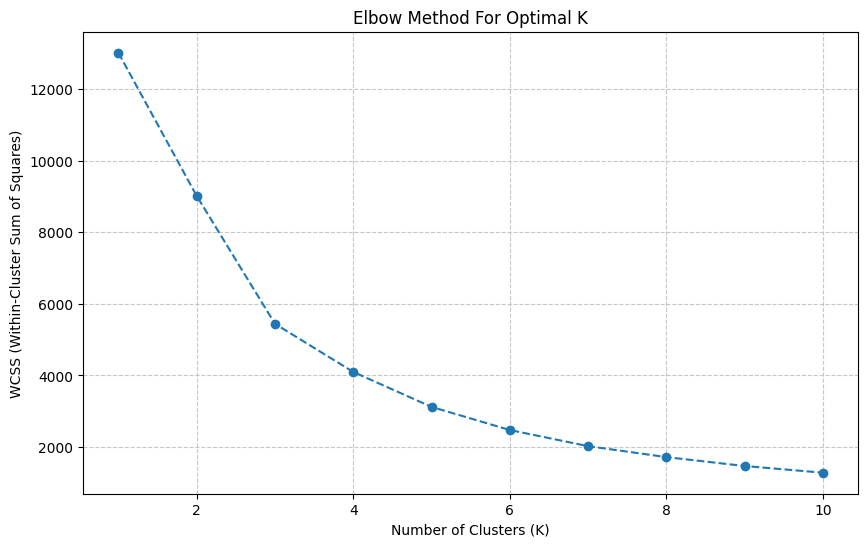

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Prepare data for clustering (exclude CustomerID)
X = rfm_final.drop('CustomerID', axis=1)

# Calculate WCSS (Within-Cluster Sum of Squares) for different number of clusters
wcss = []
for i in range(1, 11):  # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


The 'elbow' in the plot suggests a suitable number of clusters. Based on the visual inspection of the graph, we can decide on the optimal 'K' for our K-Means clustering.

#### K-Means Clustering

Having identified a suitable number of clusters (let's say K=4 from the elbow plot), we will now apply K-Means clustering to segment our customers based on their scaled RFM values. Each customer will be assigned to one of these clusters, representing a distinct customer segment.

In [76]:
# Based on the elbow plot, let's choose K=4 clusters
k = 4

kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
rfm_final['Cluster'] = kmeans.fit_predict(X)

print(f"Customers segmented into {k} clusters:")
display(rfm_final.head())


Customers segmented into 4 clusters:


,CustomerID,Recency_Scaled,Frequency_Scaled,Monetary_Scaled,Cluster
0,12346,2.334574,-0.425097,8.363010,3
1,12347,-0.905340,0.354417,0.251699,0
2,12348,-0.175360,-0.035340,-0.027988,0
3,12349,-0.735345,-0.425097,-0.032406,0
4,12350,2.174578,-0.425097,-0.190812,1


#### Analyzing Customer Segments

To understand the characteristics of each customer segment, we will group the original (unscaled) RFM data by the assigned `Cluster` and calculate the mean for Recency, Frequency, and Monetary values. This will help us interpret what each cluster represents.

In [77]:
# Merge the cluster labels back to the original RFM DataFrame
rfm_with_clusters = rfm.merge(rfm_final[['CustomerID', 'Cluster']], on='CustomerID')

# Analyze the characteristics of each cluster
cluster_summary = rfm_with_clusters.groupby('Cluster').agg(
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Customer_Count=('CustomerID', 'count')
).reset_index()

print("Cluster Summary (Mean RFM values):")
display(cluster_summary.sort_values(by='Recency_Mean'))


Cluster Summary (Mean RFM values):


,Cluster,Recency_Mean,Frequency_Mean,Monetary_Mean,Customer_Count
2,2,7.384615,82.538462,127187.959231,13
3,3,15.500000,22.333333,12690.500392,204
0,0,43.702685,3.682711,1353.625312,3054
1,1,248.075914,1.552015,478.848773,1067


#### Visualizing Cluster Characteristics

To get a clearer picture of each segment, let's visualize the average Recency, Frequency, and Monetary values for each cluster. This will help in profiling the customer segments.

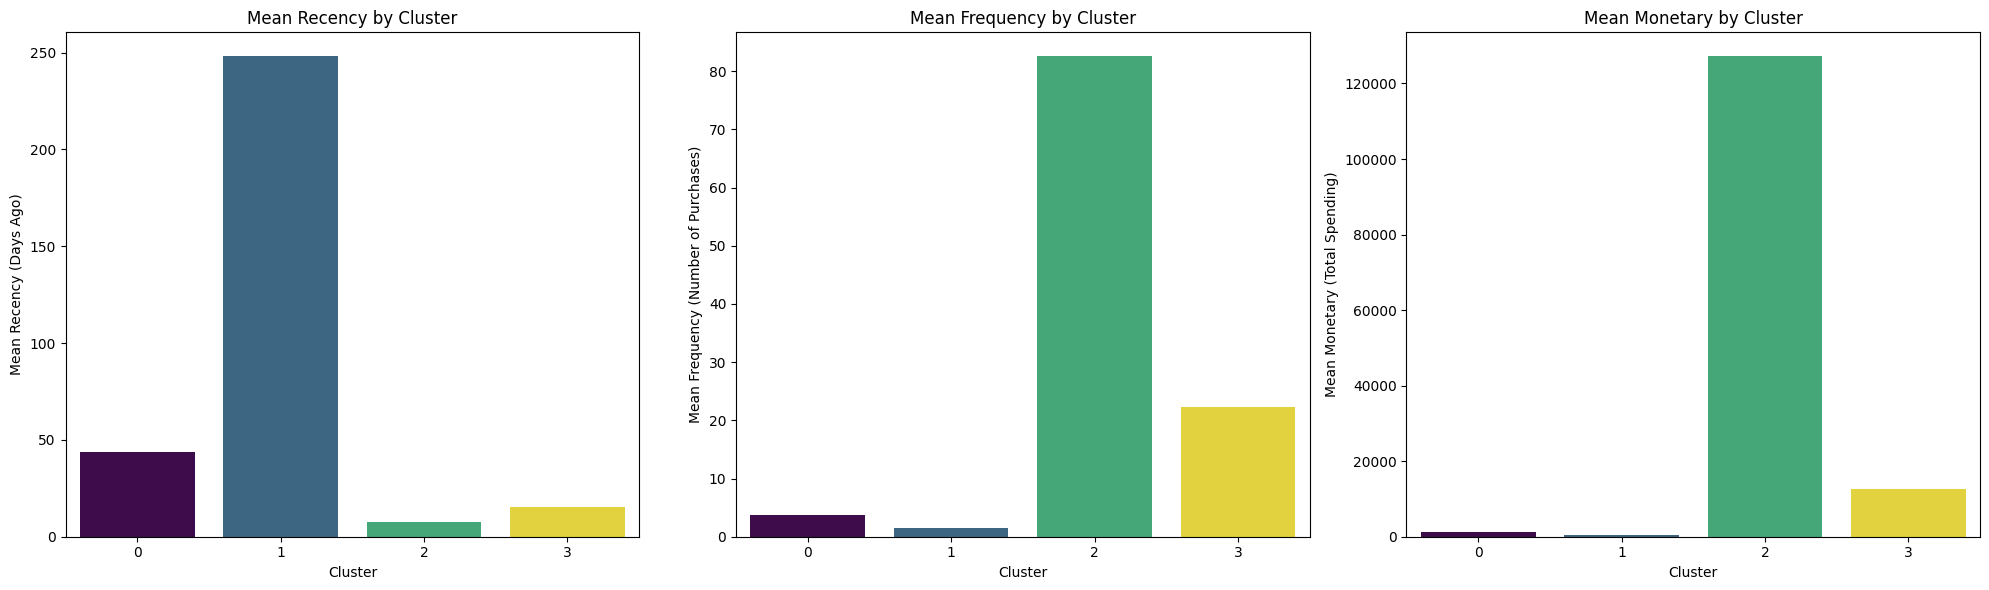

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x='Cluster', y='Recency_Mean', data=cluster_summary, ax=axes[0], palette='viridis', hue='Cluster', legend=False)
axes[0].set_title('Mean Recency by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Mean Recency (Days Ago)')

sns.barplot(x='Cluster', y='Frequency_Mean', data=cluster_summary, ax=axes[1], palette='viridis', hue='Cluster', legend=False)
axes[1].set_title('Mean Frequency by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean Frequency (Number of Purchases)')

sns.barplot(x='Cluster', y='Monetary_Mean', data=cluster_summary, ax=axes[2], palette='viridis', hue='Cluster', legend=False)
axes[2].set_title('Mean Monetary by Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Mean Monetary (Total Spending)')

plt.tight_layout()
plt.show()


### Cluster Interpretation

Based on the visualizations and the `cluster_summary` table, we can now interpret the characteristics of each cluster and assign meaningful names or descriptions to them. For example:

*   **Cluster 0 (Lowest Recency, High Frequency & Moderate Monetary):** These customers have purchased relatively recently, with good frequency, and moderate spending. They represent a significant portion of our customer base and are likely 'Engaged Customers' or 'Regulars'.
*   **Cluster 1 (Highest Recency, Lowest Frequency & Monetary):** These customers haven't purchased recently, buy infrequently, and spend the least. They might be 'Churned Customers' or 'At-Risk'.
*   **Cluster 2 (Very Low Recency, Very High Frequency & Monetary):** This small but extremely valuable segment consists of customers who buy very frequently, spend a lot, and have purchased very recently. These are our 'Best Customers' or 'Champions'.
*   **Cluster 3 (High Recency, Moderate Frequency & High Monetary):** These customers purchased somewhat recently, with moderate frequency, but have high total spending. They could be 'High-Value Recent Customers' or 'New High-Spenders' who might become champions with further engagement.

These are initial interpretations; a deeper dive into specific products purchased, customer demographics, or other behavioral data could provide even richer insights for targeted marketing and customer strategies.